In [2]:
#Data cleaning and preprocessing
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#downloading the data
from google.colab import files
uploaded = files.upload()

Saving Books_Raw_Data.csv to Books_Raw_Data (1).csv


In [5]:
#Load data
df = pd.read_csv("Books_Raw_Data.csv")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 1000
Columns: 4


,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five


In [6]:
#Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Title           0
Price           0
Availability    0
Rating          0
dtype: int64


In [7]:
#Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
#Remove duplicates
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 1000


In [9]:
#Clean Price
df["Price"] = (
    df["Price"]
    .str.replace("Â", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print(df["Price"].dtype)
print(df["Price"].isnull().sum())

float64
0


In [10]:
#print(df["Price"].dtype)
print(df["Price"].head())
print(df["Price"].isnull().sum())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64
0


In [11]:
#Convert Rating from words to numbers
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

print(df["Rating"].head())
print(df["Rating"].isnull().sum())


0    3
1    1
2    1
3    4
4    5
Name: Rating, dtype: int64
0


In [12]:
#Create price category
df["Price_Category"] = pd.cut(
    df["Price"],
    bins=[0, 20, 40, 60, 100],
    labels=["Low", "Medium", "High", "Very High"]
)

df[["Price", "Price_Category"]].head()

,Price,Price_Category
0,51.77,High
1,53.74,High
2,50.10,High
3,47.82,High
4,54.23,High


In [13]:
# create rating category
df["Rating_Category"] = pd.cut(
    df["Rating"],
    bins=[0, 2, 3, 4, 5],
    labels=["Poor", "Average", "Good", "Excellent"],
    include_lowest=True
)

df[["Rating", "Rating_Category"]].head()

,Rating,Rating_Category
0,3,Average
1,1,Poor
2,1,Poor
3,4,Good
4,5,Excellent


In [14]:
#Final data check
print(df.info())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Title            1000 non-null   object  
 1   Price            1000 non-null   float64 
 2   Availability     1000 non-null   object  
 3   Rating           1000 non-null   int64   
 4   Price_Category   1000 non-null   category
 5   Rating_Category  1000 non-null   category
dtypes: category(2), float64(1), int64(1), object(2)
memory usage: 33.7+ KB
None
Title              0
Price              0
Availability       0
Rating             0
Price_Category     0
Rating_Category    0
dtype: int64
Duplicates: 0


In [15]:
#Save cleaned data
df.to_csv("Books_Cleaned_Data.csv", index=False)

print("Books_Cleaned_Data.csv created successfully")

Books_Cleaned_Data.csv created successfully


In [16]:
#EDA and Visualization
#Basic statistics
df.describe()

,Price,Rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


In [18]:
#Average price
print("Average Price:", round(df["Price"].mean(), 2))

Average Price: 35.07


In [19]:
#Average Rating
print("Average Rating:", round(df["Rating"].mean(), 2))


Average Rating: 2.92


In [20]:
#Highest Price
print("Highest Price:", df["Price"].max())

Highest Price: 59.99


In [21]:
#Lowest Price
print("Lowest Price:", df["Price"].min())

Lowest Price: 10.0


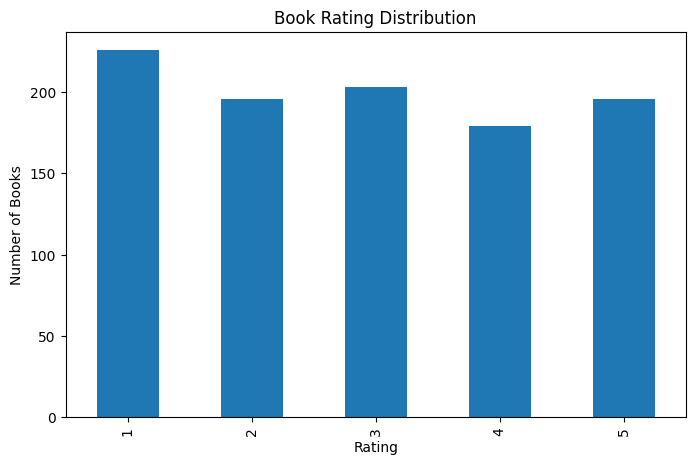

In [22]:
#Rating Distribution
plt.figure(figsize=(8,5))

df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

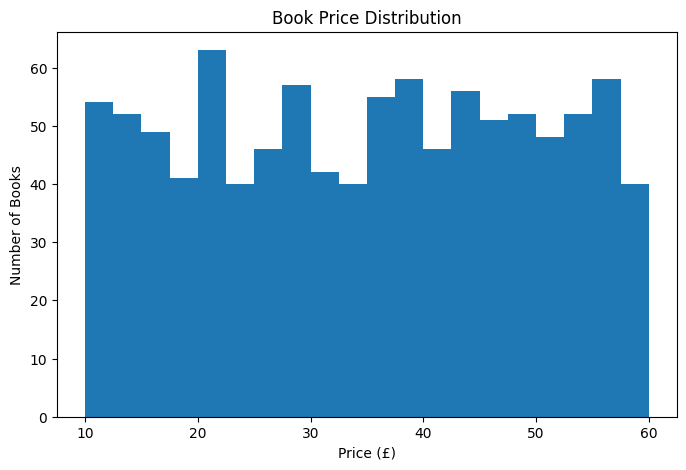

In [23]:
#Price Distribution
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=20)

plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

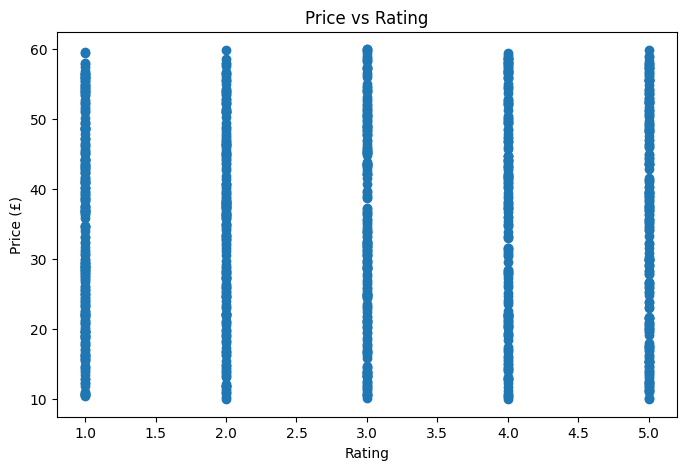

In [24]:
# price vs Rating
plt.figure(figsize=(8,5))

plt.scatter(df["Rating"], df["Price"])

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.show()

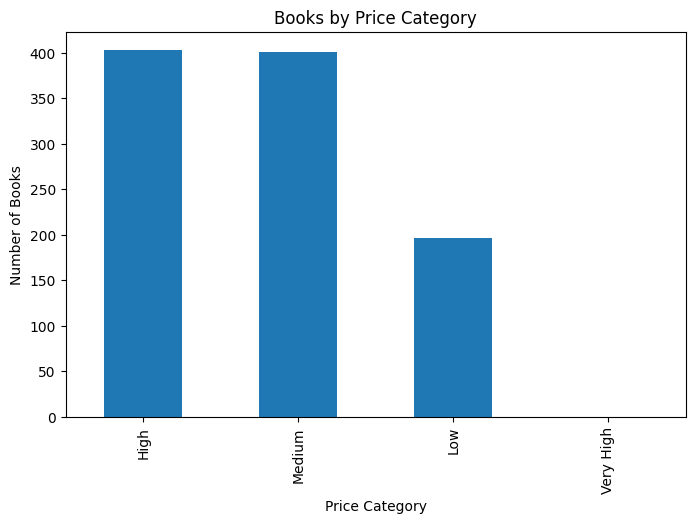

In [25]:
#Books by Price category
plt.figure(figsize=(8,5))

df["Price_Category"].value_counts().plot(kind="bar")

plt.title("Books by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Books")

plt.show()

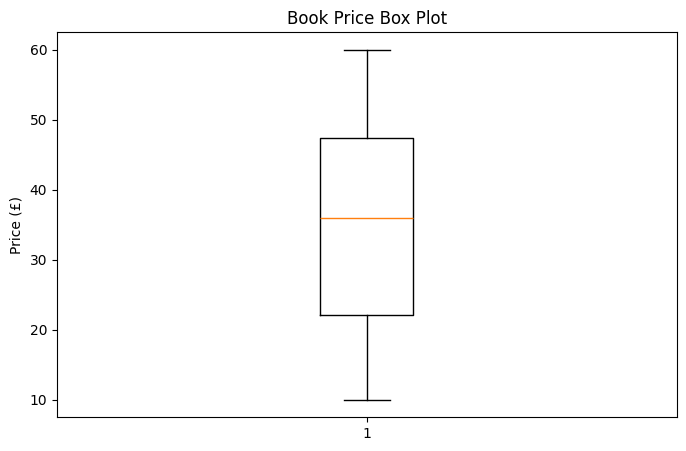

In [26]:
#Box plot
plt.figure(figsize=(8,5))

plt.boxplot(df["Price"])

plt.title("Book Price Box Plot")
plt.ylabel("Price (£)")

plt.show()

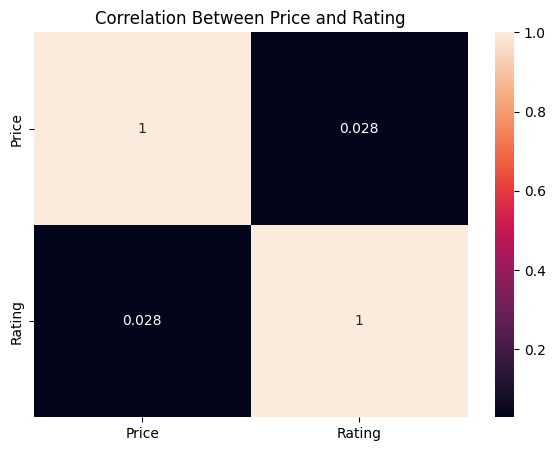

In [27]:
# correlation heatmap
plt.figure(figsize=(7,5))

correlation = df[["Price", "Rating"]].corr()

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Between Price and Rating")
plt.show()

In [28]:
# Machine Learning
#Create target column
df["High_Rating"] = (df["Rating"] >= 4).astype(int)

df[["Price", "Rating", "High_Rating"]].head()

,Price,Rating,High_Rating
0,51.77,3,0
1,53.74,1,0
2,50.10,1,0
3,47.82,4,1
4,54.23,5,1


In [29]:
#Import ML liabraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [30]:
#Create X and Y
X = df[["Price"]]

y = df["High_Rating"]

In [31]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 800
Testing records: 200


In [32]:
# create model
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

In [33]:
# Train model
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [34]:
# Make prediction
y_pred = model.predict(X_test)

In [35]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 58.5 %


In [36]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[109  11]
 [ 72   8]]


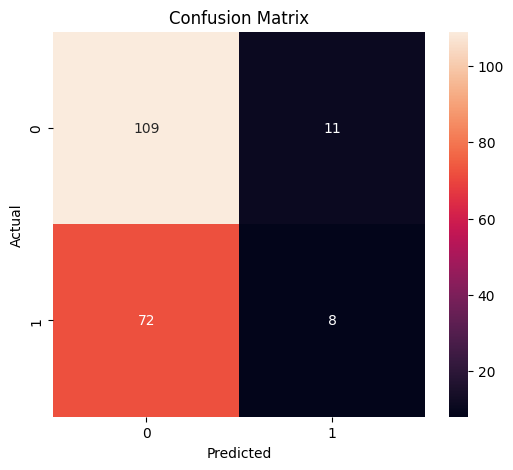

In [37]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
#Classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.60      0.91      0.72       120
           1       0.42      0.10      0.16        80

    accuracy                           0.58       200
   macro avg       0.51      0.50      0.44       200
weighted avg       0.53      0.58      0.50       200



In [39]:
# save the model
import joblib

joblib.dump(model, "Book_Rating_Model.pkl")

print("ML model saved successfully")

ML model saved successfully


In [40]:
print(df.shape)
print(df.head())
print(df.columns)

(1000, 7)
                                   Title  Price Availability  Rating  \
0                   A Light in the Attic  51.77     In stock       3   
1                     Tipping the Velvet  53.74     In stock       1   
2                             Soumission  50.10     In stock       1   
3                          Sharp Objects  47.82     In stock       4   
4  Sapiens: A Brief History of Humankind  54.23     In stock       5   

  Price_Category Rating_Category  High_Rating  
0           High         Average            0  
1           High            Poor            0  
2           High            Poor            0  
3           High            Good            1  
4           High       Excellent            1  
Index(['Title', 'Price', 'Availability', 'Rating', 'Price_Category',
       'Rating_Category', 'High_Rating'],
      dtype='object')


In [41]:
df.to_csv("Books_Cleaned_Data.csv", index=False)

print("Books_Cleaned_Data.csv created successfully!")

Books_Cleaned_Data.csv created successfully!


In [42]:
from google.colab import files

files.download("Books_Cleaned_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 58.5 %


In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.91      0.72       120
           1       0.42      0.10      0.16        80

    accuracy                           0.58       200
   macro avg       0.51      0.50      0.44       200
weighted avg       0.53      0.58      0.50       200

